# Acceso y limpieza de datos

In [4]:
%pip install seaborn matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
ruta = Path('..') / '..' / 'Fuentes/Studio_Ghibli.csv'
with open(ruta, 'r', encoding='utf-8') as f:
    df = pd.read_csv(f)

In [3]:
# Convertir la columna 'Duration' a minutos
def convertir_a_minutos(duracion):
	partes = duracion.split('h')
	horas = int(partes[0].strip())
	minutos = int(partes[1].replace('m', '').strip()) if len(partes) > 1 else 0
	return horas * 60 + minutos

df['Duration'] = df['Duration'].apply(convertir_a_minutos)

In [6]:
# Crear un DataFrame con los géneros asociados a cada director
director_genres = df.melt(id_vars=['Director'], value_vars=['Genre 1', 'Genre 2', 'Genre 3'], 
						  var_name='Genre_Type', value_name='Genre').dropna()

# Contar la cantidad de veces que cada director ha trabajado en cada género
director_genre_counts = director_genres.groupby(['Director', 'Genre']).size().reset_index(name='Count')

# Calcular el total de géneros en los que ha trabajado cada director
director_total_genres = director_genre_counts.groupby('Director')['Count'].sum().reset_index(name='Total')

# Unir los datos para calcular el porcentaje
director_genre_percentage = pd.merge(director_genre_counts, director_total_genres, on='Director')
director_genre_percentage['Percentage'] = director_genre_percentage['Count'] / director_genre_percentage['Total']

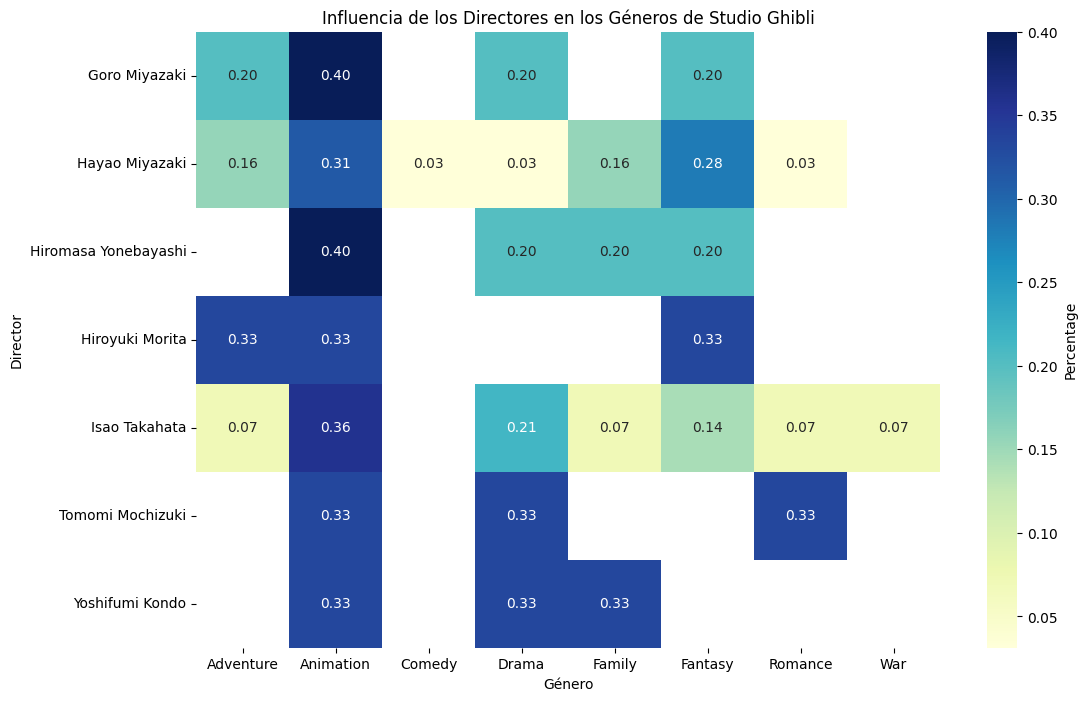

In [11]:
# Crear una tabla pivote para el mapa de calor
heatmap_data = director_genre_percentage.pivot(index="Director", columns="Genre", values="Percentage")

# Crear el mapa de calor
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="YlGnBu", cbar_kws={'label': 'Percentage'})
plt.title("Influencia de los Directores en los Géneros de Studio Ghibli")
plt.xlabel("Género")
plt.ylabel("Director")
plt.show()